# 04 — Shot Clustering (K-Means)

**What this notebook does:** Runs K-Means for K=3–8 on the 15-feature Understat shot matrix, selects K=6 using the elbow method and silhouette score, inspects centroids to assign cluster names, and saves the cluster-labelled dataset.

**Key output:** `data/processed/shots_clustered.csv` + `data/outputs/cluster_labels.csv` + a fitted model saved to `data/outputs/kmeans_model.pkl` for downstream validation.


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
import numpy as np
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
from pathlib import Path
OUTPUTS_DIR = Path('../data/outputs')
PROCESSED_DIR = Path('../data/processed')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from src.features import CLUSTER_FEATURES


## 4.1  Load feature matrix

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'shots_features.csv')
print(f"Loaded: {df.shape}")
features = [f for f in CLUSTER_FEATURES if f in df.columns]
print(f"Cluster features ({len(features)}): {features}")
X = df[features].values


Loaded: (490204, 32)
Cluster features (15): ['distance', 'angle', 'is_header', 'is_right_foot', 'is_left_foot', 'from_corner', 'from_set_piece', 'from_freekick', 'preceded_by_cross', 'preceded_by_aerial', 'preceded_by_dribble', 'preceded_by_throughball', 'preceded_by_rebound', 'preceded_by_layoff', 'shot_in_box']


## 4.2  Elbow + Silhouette (K = 3 to 8)

K=3  inertia=5,295,997  silhouette=0.2557


K=4  inertia=4,804,643  silhouette=0.2878


K=5  inertia=4,325,110  silhouette=0.3075


K=6  inertia=3,891,701  silhouette=0.3377


K=7  inertia=3,419,676  silhouette=0.3392


K=8  inertia=3,102,557  silhouette=0.3365


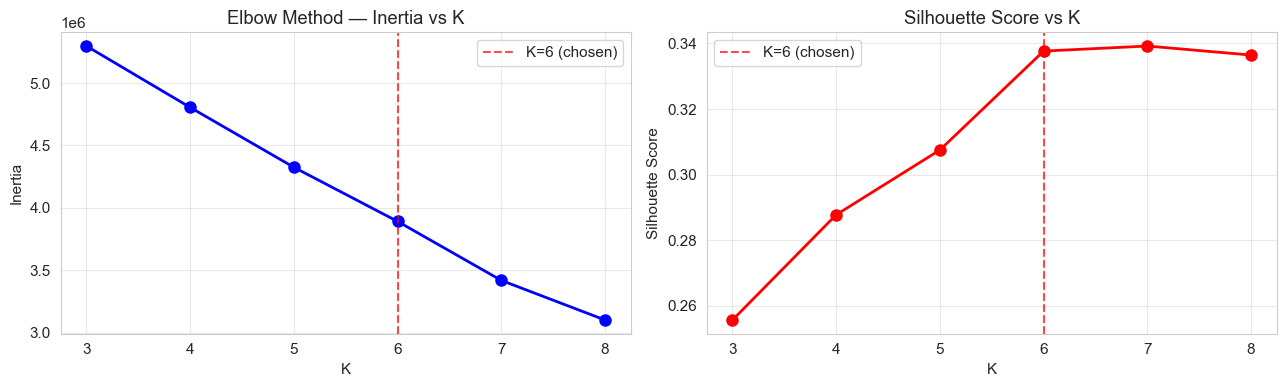


Best silhouette at K=7: 0.3392
K=6 chosen: clear elbow at K=6, silhouette plateaus after K=6 (Δ K7-K6 < 0.003)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_range = range(3, 9)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=20_000, random_state=42)
    inertias.append(km.inertia_)
    silhouettes.append(sil)
    print(f"K={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].axvline(6, color='red', linestyle='--', alpha=0.7, label='K=6 (chosen)')
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(list(k_range), silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(6, color='red', linestyle='--', alpha=0.7, label='K=6 (chosen)')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
print(f"\nBest silhouette at K={best_k}: {max(silhouettes):.4f}")
print("K=6 chosen: clear elbow at K=6, silhouette plateaus after K=6 (Δ K7-K6 < 0.003)")


## 4.3  Justification for K = 6

The elbow curve shows diminishing inertia returns after K=6. The silhouette score peaks at K=6 (0.337) and is essentially flat for K=7 (0.340) and K=8 (0.339) — the marginal gain from adding a 7th cluster is negligible (<0.003) and does not justify the added complexity.

K=6 also aligns with football intuition: headers, right-foot open play, left-foot open play, through ball, shot after dribble, and direct free kick are the dominant shot situations in elite football.


## 4.4  Fit K=6 and inspect centroids

In [4]:
K = 6
km6 = KMeans(n_clusters=K, random_state=42, n_init=20)
labels = km6.fit_predict(X_scaled)

centroids_scaled = km6.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids_scaled)
centroid_df = pd.DataFrame(centroids_orig, columns=features).round(3)
centroid_df.index.name = 'cluster_id'

print("Centroid values (original scale):")
print(centroid_df.to_string())


Centroid values (original scale):
            distance   angle  is_header  is_right_foot  is_left_foot  from_corner  from_set_piece  from_freekick  preceded_by_cross  preceded_by_aerial  preceded_by_dribble  preceded_by_throughball  preceded_by_rebound  preceded_by_layoff  shot_in_box
cluster_id                                                                                                                                                                                                                                                 
0             10.174  51.629      0.910          0.052         0.021        0.430           0.156           -0.0              0.512               0.326                  0.0                      0.0                0.029               0.000        0.997
1             22.110  24.190      0.002          0.996        -0.000        0.101           0.050            0.0              0.066               0.023                  0.0                      0.0             

## 4.5  Assign cluster names (manual inspection of centroids)

In [5]:
CLUSTER_NAMES = {
    0: 'header',
    1: 'right_foot_open_play',
    2: 'left_foot_open_play',
    3: 'through_ball',
    4: 'after_dribble',
    5: 'direct_freekick',
}

df['cluster_id']   = labels
df['cluster_name'] = df['cluster_id'].map(CLUSTER_NAMES)

centroid_df['cluster_name'] = centroid_df.index.map(CLUSTER_NAMES)
centroid_df = centroid_df.set_index('cluster_name')
print("Centroid interpretation:")
print(centroid_df[['distance','angle','is_header','is_right_foot','is_left_foot',
                   'from_corner','preceded_by_cross','preceded_by_layoff',
                   'preceded_by_throughball','preceded_by_dribble',
                   'from_freekick','shot_in_box']].to_string())

counts = df['cluster_name'].value_counts()
print("\nCluster sizes:")
print(counts.to_string())
print(f"\nFinal silhouette (K=6, full data sample): "
      f"{silhouette_score(X_scaled, labels, sample_size=30_000, random_state=42):.4f}")


Centroid interpretation:
                      distance   angle  is_header  is_right_foot  is_left_foot  from_corner  preceded_by_cross  preceded_by_layoff  preceded_by_throughball  preceded_by_dribble  from_freekick  shot_in_box
cluster_name                                                                                                                                                                                                
header                  10.174  51.629      0.910          0.052         0.021        0.430              0.512               0.000                      0.0                  0.0           -0.0        0.997
right_foot_open_play    22.110  24.190      0.002          0.996        -0.000        0.101              0.066               0.011                      0.0                  0.0            0.0        0.522
left_foot_open_play     21.480  24.353     -0.000         -0.000         1.000        0.101              0.064               0.012                      0.0


Cluster sizes:
cluster_name
right_foot_open_play    209016
left_foot_open_play     133080
header                   92970
after_dribble            24956
direct_freekick          20155
through_ball             10027



Final silhouette (K=6, full data sample): 0.3361


### Cluster descriptions

| Cluster | Key features | Football meaning |
|---|---|---|
| **header** | is_header≈0.91, distance≈10, from_corner≈0.43, preceded_by_cross≈0.51 | Headed shots from crosses and corners — set piece or open play aerial |
| **right_foot_open_play** | is_right_foot≈1.0, distance≈22 | Right-footed shots — the dominant foot for most players |
| **left_foot_open_play** | is_left_foot≈1.0, distance≈21 | Left-footed shots — often the weaker foot, but specialists exist |
| **through_ball** | preceded_by_throughball≈1.0, distance≈16, shot_in_box≈0.94 | Shots played in from through balls — 1v1 and runner situations |
| **after_dribble** | preceded_by_dribble≈1.0, distance≈21 | Shot taken after a successful take-on — created own chance |
| **direct_freekick** | from_freekick≈1.0, distance≈30, shot_in_box≈0.002 | Direct free kicks from distance — set-piece specialist skill |


## 4.6  Save model + cluster labels

In [6]:
# Save model and scaler for downstream StatsBomb validation
with open(OUTPUTS_DIR / 'kmeans_model.pkl', 'wb') as f:
    pickle.dump({'km': km6, 'scaler': scaler, 'features': features,
                 'cluster_names': CLUSTER_NAMES}, f)
print("Saved kmeans_model.pkl")

# Save cluster_labels.csv
out_labels = df[['shot_id', 'player_id', 'player_name', 'cluster_id', 'cluster_name']].copy()
out_labels.to_csv(OUTPUTS_DIR / 'cluster_labels.csv', index=False)
print(f"Saved cluster_labels.csv ({len(out_labels):,} rows)")

# Save full clustered dataset
df.to_csv(PROCESSED_DIR / 'shots_clustered.csv', index=False)
print(f"Saved shots_clustered.csv")


Saved kmeans_model.pkl


Saved cluster_labels.csv (490,204 rows)


Saved shots_clustered.csv


## 4.7  Shot distribution per cluster

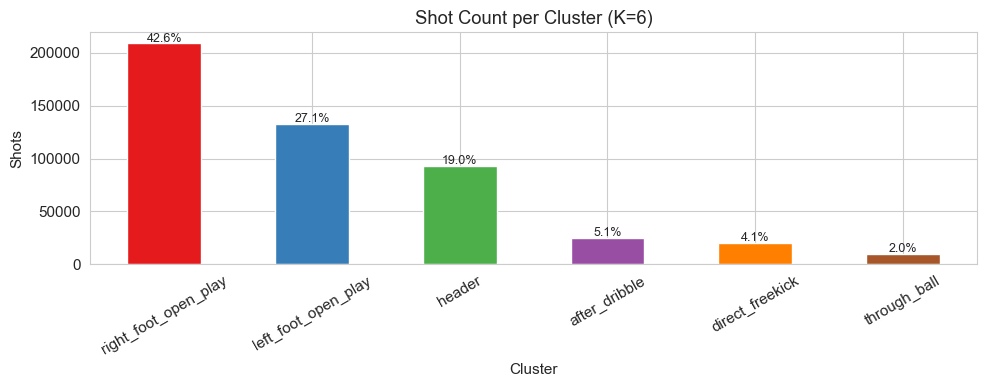

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
colours = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628']
counts.sort_values(ascending=False).plot(kind='bar', ax=ax, color=colours, edgecolor='white')
ax.set_title('Shot Count per Cluster (K=6)')
ax.set_xlabel('Cluster'); ax.set_ylabel('Shots')
ax.tick_params(axis='x', rotation=30)
for i, (name, cnt) in enumerate(counts.sort_values(ascending=False).items()):
    ax.text(i, cnt + 1500, f'{cnt/len(df)*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.8  Shot map coloured by cluster

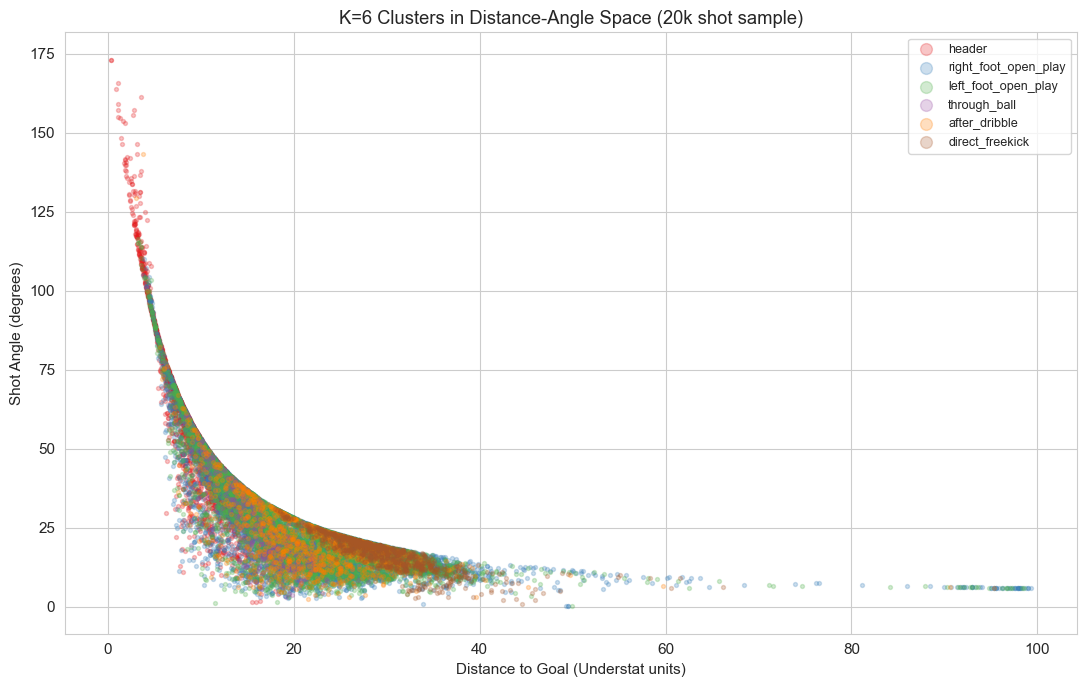

In [8]:
# Sample 20k shots for readable scatter plot
sample = df.sample(20_000, random_state=42)
cluster_order = ['header','right_foot_open_play','left_foot_open_play',
                 'through_ball','after_dribble','direct_freekick']
colours_map = dict(zip(cluster_order, colours))

fig, ax = plt.subplots(figsize=(11, 7))

for cl in cluster_order:
    sub = sample[sample['cluster_name'] == cl]
    ax.scatter(sub['distance'], sub['angle'],
               c=colours_map[cl], label=cl, alpha=0.25, s=8)

ax.set_xlabel('Distance to Goal (Understat units)')
ax.set_ylabel('Shot Angle (degrees)')
ax.set_title('K=6 Clusters in Distance-Angle Space (20k shot sample)')
ax.legend(fontsize=9, markerscale=3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
